In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)


In [17]:
train_data = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)
test_data = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes')
)
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

print("training documents:", len(X_train_text))
print("testing documents:", len(X_test_text))
print("Number of classes:", len(train_data.target_names))


training documents: 11314
testing documents: 7532
Number of classes: 20


In [19]:
vectorizer = CountVectorizer(
    stop_words='english',
    min_df=2,
)

X_train_multi = vectorizer.fit_transform(X_train_text)
X_test_multi = vectorizer.transform(X_test_text)

print("\nMultinomial feature matrix:")
print("Training shape:", X_train_multi.shape)
print("Testing shape:", X_test_multi.shape)



Multinomial feature matrix:
Training shape: (11314, 39115)
Testing shape: (7532, 39115)


In [13]:
vectorizer_bern = CountVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=2,
    max_df=0.95,
    binary=True
)

X_train_bern = vectorizer_bern.fit_transform(X_train_text)
X_test_bern = vectorizer_bern.transform(X_test_text)

print("\nBernoulli feature matrix:")
print("Training shape:", X_train_bern.shape)
print("Testing shape:", X_test_bern.shape)




Bernoulli feature matrix:
Training shape: (11314, 39115)
Testing shape: (7532, 39115)


In [25]:
mnb = MultinomialNB()
mnb.fit(X_train_multi, y_train)
y_pred_multi = mnb.predict(X_test_multi)
bnb = BernoulliNB()
bnb.fit(X_train_bern, y_train)

y_pred_bern = bnb.predict(X_test_bern)

mnb_accuracy = accuracy_score(y_test, y_pred_multi)

mnb_precision = precision_score(
    y_test,
    y_pred_multi,
    average='macro',
    zero_division=0
)

mnb_recall = recall_score(
    y_test,
    y_pred_multi,
    average='macro',
    zero_division=0
)

mnb_f1 = f1_score(
    y_test,
    y_pred_multi,
    average='macro',
    zero_division=0
)

bnb_accuracy = accuracy_score(y_test, y_pred_bern)

bnb_precision = precision_score(
    y_test,
    y_pred_bern,
    average='macro',
    zero_division=0
)

bnb_recall = recall_score(
    y_test,
    y_pred_bern,
    average='macro',
    zero_division=0
)

bnb_f1 = f1_score(
    y_test,
    y_pred_bern,
    average='macro',
    zero_division=0
)

print("       MULTINOMIAL NAIVE BAYES RESULTS")

print("Accuracy  :", mnb_accuracy)
print("Precision :", mnb_precision)
print("Recall    :", mnb_recall)
print("F1-score  :", mnb_f1)

print("        BERNOULLI NAIVE BAYES RESULTS")

print("Accuracy  :", bnb_accuracy)
print("Precision :", bnb_precision)
print("Recall    :", bnb_recall)
print("F1-score  :", bnb_f1)

print("                 COMPARISON")
print("\n                    Multinomial    Bernoulli")
print("----------------------------------------------")
print("Accuracy            {:.4f}        {:.4f}".format(
    mnb_accuracy, bnb_accuracy
))

print("Precision           {:.4f}        {:.4f}".format(
    mnb_precision, bnb_precision
))

print("Recall              {:.4f}        {:.4f}".format(
    mnb_recall, bnb_recall
))

print("F1-score            {:.4f}        {:.4f}".format(
    mnb_f1, bnb_f1
))


if mnb_f1 > bnb_f1:
    print("\nMultinomial Naive Bayes performs better based on F1-score.")
elif bnb_f1 > mnb_f1:
    print("\nBernoulli Naive Bayes performs better based on F1-score.")
else:
    print("\nBoth models have the same F1-score.")


       MULTINOMIAL NAIVE BAYES RESULTS
Accuracy  : 0.6510886882634095
Precision : 0.6344696928587387
Recall    : 0.6369333927687648
F1-score  : 0.6178588701948873
        BERNOULLI NAIVE BAYES RESULTS
Accuracy  : 0.4851301115241636
Precision : 0.6166775686678625
Recall    : 0.46943426113187225
F1-score  : 0.46786548654913174
                 COMPARISON

                    Multinomial    Bernoulli
----------------------------------------------
Accuracy            0.6511        0.4851
Precision           0.6345        0.6167
Recall              0.6369        0.4694
F1-score            0.6179        0.4679

Multinomial Naive Bayes performs better based on F1-score.


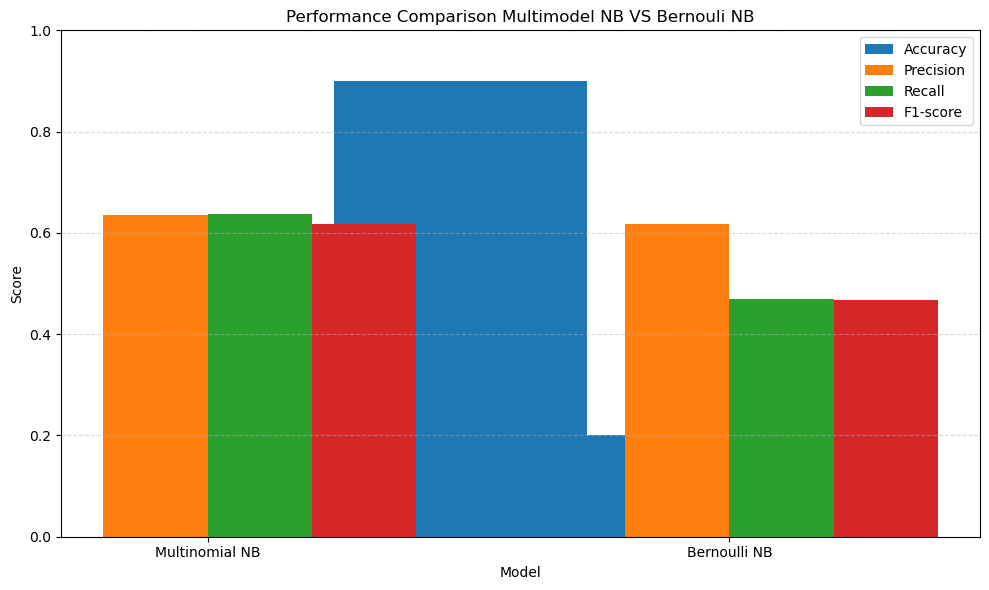

In [34]:
models = ['Multinomial NB', 'Bernoulli NB']
accuracy = [mnb_accuracy, bnb_accuracy]
precision = [mnb_precision, bnb_precision]
recall = [mnb_recall, bnb_recall]
f1 = [mnb_f1, bnb_f1]
x = np.arange(len(models))
width = 0.2
plt.figure(figsize=(10, 6))
plt.bar(x - 1.5 * width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5 * width, precision, width, label='Precision')
plt.bar(x + 0.5 * width, recall, width, label='Recall')
plt.bar(x + 1.5 * width, f1, width, label='F1-score')
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Performance Comparison Multimodel NB VS Bernouli NB')
plt.xticks(x, models)
plt.ylim(0, 1)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Target documents : 11314
Testing documents : 7532
Number of classes : 20
training feature matrix (11314, 39115)
test feature matrix (7532, 39115)
            Model  Accuracy  Precision    Recall  F1-Score
0  Multinomial NB  0.651089   0.634470  0.636933  0.617859
1    Bernoulli NB  0.485130   0.616678  0.469434  0.467865


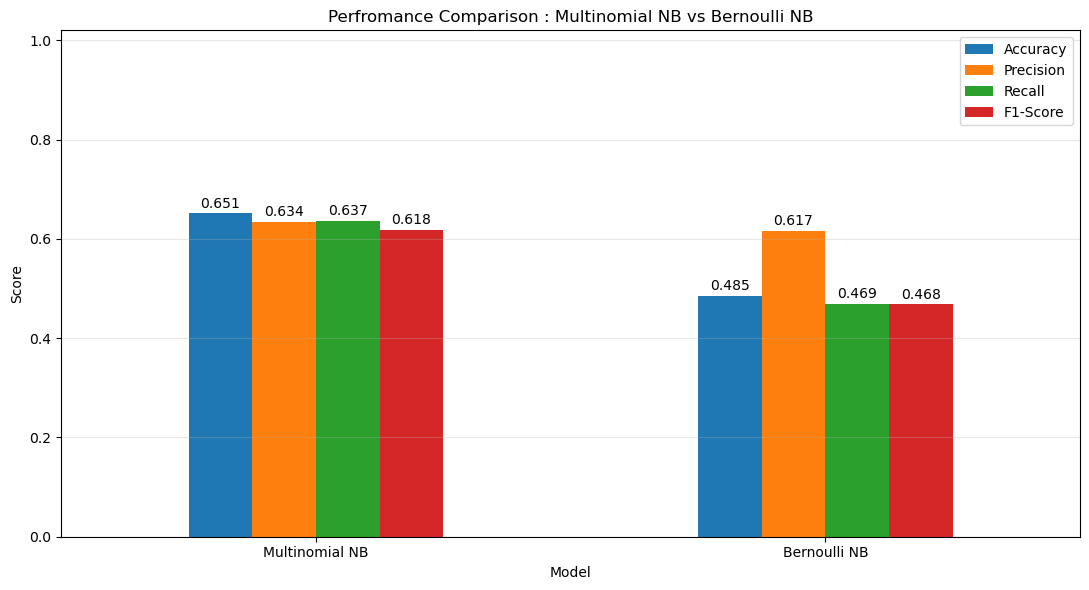

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import(accuracy_score,f1_score,precision_score,recall_score) 

train_data=fetch_20newsgroups(subset="train",remove=("headers","footers","quotes"))
test_data=fetch_20newsgroups(subset="test",remove=("headers","footers","quotes"))
X_train_text=train_data.data
y_train=train_data.target
X_test_text=test_data.data
y_test=test_data.target
class_names=train_data.target_names


print("Target documents :",len(X_train_text))
print("Testing documents :",len(X_test_text))
print("Number of classes :",len(class_names))

vectorizer=CountVectorizer(stop_words="english",min_df=2)
X_train=vectorizer.fit_transform(X_train_text)
X_test=vectorizer.transform(X_test_text)
print("training feature matrix",X_train.shape)
print("test feature matrix",X_test.shape)

mnb=MultinomialNB()
mnb.fit(X_train,y_train)
y_pred_mnb=mnb.predict(X_test)

binary_vectorizer=CountVectorizer(stop_words="english",min_df=2,binary=True)
X_train_binary=binary_vectorizer.fit_transform(X_train_text)
X_test_binary=binary_vectorizer.transform(X_test_text)

bnb=BernoulliNB()
bnb.fit(X_train_binary,y_train)
y_pred_bnb=bnb.predict(X_test_binary)

results=pd.DataFrame({
    "Model":[
    "Multinomial NB",
    "Bernoulli NB"
    ],
    "Accuracy":[
         accuracy_score(y_test,y_pred_mnb),
        accuracy_score(y_test,y_pred_bnb),
    ],
    "Precision":[
        precision_score(y_test,y_pred_mnb,average="macro"),
        precision_score(y_test,y_pred_bnb,average="macro"),
    ],
    "Recall":[
     recall_score(y_test,y_pred_mnb,average="macro"),
    recall_score(y_test,y_pred_bnb,average="macro"),
    ],
     "F1-Score":[
     f1_score(y_test,y_pred_mnb,average="macro"),
    f1_score(y_test,y_pred_bnb,average="macro"),
    ]
})
print(results)

results_metrics=results[
    ["Model","Accuracy","Precision","Recall","F1-Score"]
]

ax=results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11,6)
)
plt.title("Perfromance Comparison : Multinomial NB vs Bernoulli NB")
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0,1.02)
plt.xticks(rotation=0)

plt.grid(axis="y",
        alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2
    )
plt.tight_layout()
plt.show()